# Lab 04: Clustering and Association Rule Learning
## E/21/245




### **Exercise 01**

#### 1. Loading the dataset & dropping Labels

In [9]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

In [3]:
# Load the iris dataset
iris = load_iris()
X = iris.data  # Features (Sepal length, Sepal width, Petal length, Petal width)
y_true = iris.target  # Kept separately only for evaluation later

In [4]:
# Convert to DataFrame for easier inspection
df = pd.DataFrame(X, columns=iris.feature_names)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


#### 2: Finding Optimal $k$ via the Elbow Method

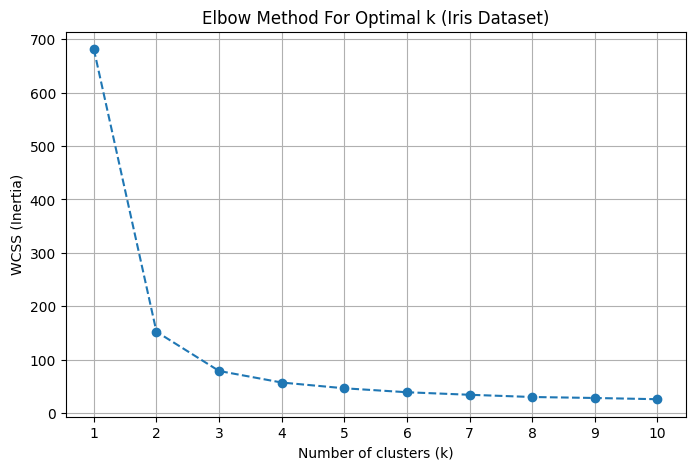

In [6]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k (Iris Dataset)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

#### 3. Fitting K-Means with Optimal $k$

In [7]:
# Fitting K-Means with k = 3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X)

print("Clustering completed. Labels assigned to all samples.")

Clustering completed. Labels assigned to all samples.


#### 4.Interpreting kmeans.cluster_centers_

In [8]:
# Inspecting cluster centers
centers = kmeans.cluster_centers_
print("Cluster Centers Matrix:\n", centers)

Cluster Centers Matrix:
 [[5.9016129  2.7483871  4.39354839 1.43387097]
 [5.006      3.428      1.462      0.246     ]
 [6.85       3.07368421 5.74210526 2.07105263]]


#### 5: 3D Visualization of Clusters

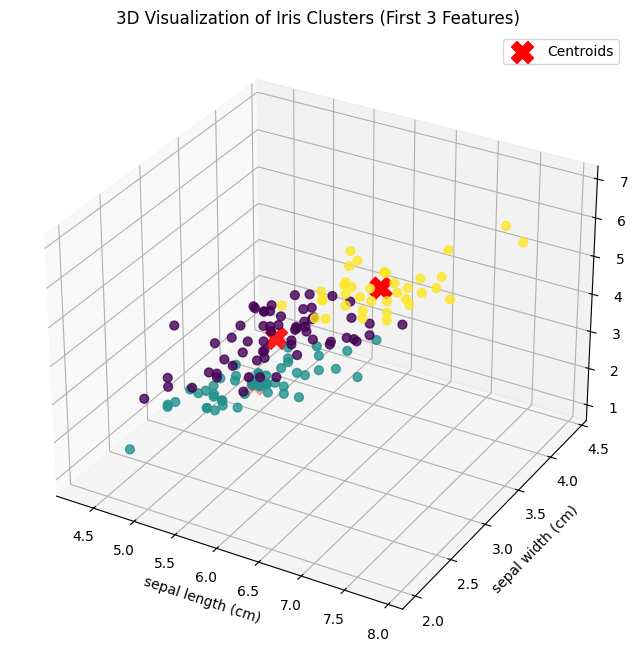

In [10]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for the data points colored by cluster assignment
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=cluster_labels, cmap='viridis', s=40, alpha=0.8)

# Scatter plot for the cluster centroids
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='red', marker='X', s=250, label='Centroids')

ax.set_title('3D Visualization of Iris Clusters (First 3 Features)')
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.legend()
plt.show()

#### 6: Silhouette Score Analysis

In [11]:
from sklearn.metrics import silhouette_score

print("Silhouette Scores:")
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"k = {k} : Silhouette Score = {score:.4f}")

Silhouette Scores:
k = 2 : Silhouette Score = 0.6810
k = 3 : Silhouette Score = 0.5528
k = 4 : Silhouette Score = 0.4981
k = 5 : Silhouette Score = 0.4912
k = 6 : Silhouette Score = 0.3648
k = 7 : Silhouette Score = 0.3543
k = 8 : Silhouette Score = 0.3487
k = 9 : Silhouette Score = 0.3125
k = 10 : Silhouette Score = 0.3180


#### 7: Adjusted Rand Score (ARI)

In [12]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(y_true, cluster_labels)
print(f"Adjusted Rand Score for k=3: {ari:.4f}")

Adjusted Rand Score for k=3: 0.7302


##### 8: Impact of Initialization (n_init & Random State)

In [13]:
# Run 1
km1 = KMeans(n_clusters=3, n_init=1, random_state=10)
km1.fit(X)
print("Run 1 (RS 10) Inertia:", km1.inertia_)

# Run 2
km2 = KMeans(n_clusters=3, n_init=1, random_state=99)
km2.fit(X)
print("Run 2 (RS 99) Inertia:", km2.inertia_)

Run 1 (RS 10) Inertia: 78.85566582597727
Run 2 (RS 99) Inertia: 78.851441426146


#### 9: K-Means vs. DBSCAN on Non-Spherical Data

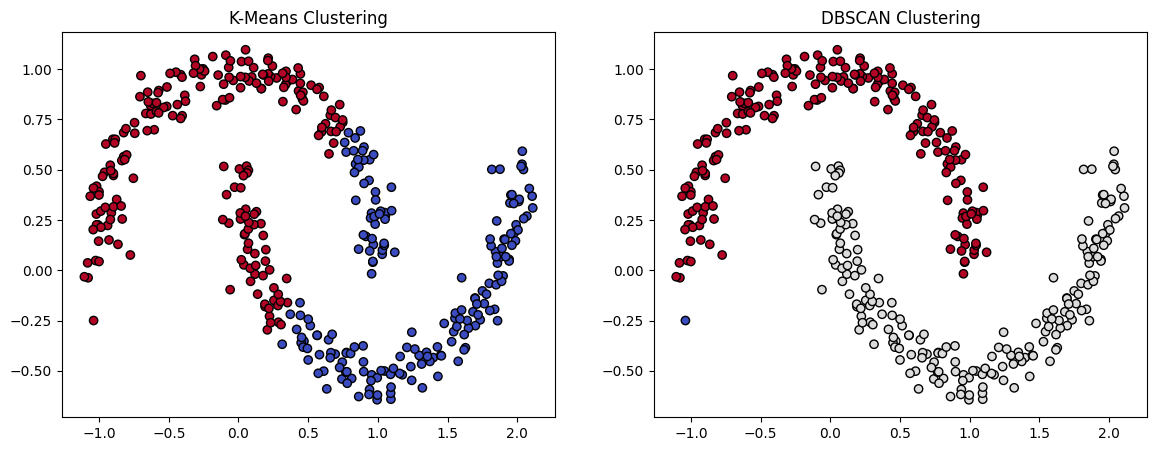

In [14]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Generate dataset
X_moons, y_moons = make_moons(n_samples=400, noise=0.07, random_state=42)

# Fit K-Means
km_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_km = km_moons.fit_predict(X_moons)

# Fit DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X_moons)

# Plot side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km, cmap='coolwarm', edgecolors='k')
ax1.set_title("K-Means Clustering")

ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_db, cmap='coolwarm', edgecolors='k')
ax2.set_title("DBSCAN Clustering")

plt.show()

## Exercise 02

In [26]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [27]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', message='.*utcnow.*')

#### 1: Import the groceries.csv dataset

In [28]:
file_path = "groceries.csv"  # Assumes file is directly in your files tab

transactions = []
with open(file_path, 'r') as f:
    for line in f:
        # Remove whitespace and split row items by comma
        row = [item.strip() for item in line.strip().split(',') if item.strip()]
        if row:
            transactions.append(row)

print(f"Dataset successfully loaded directly from environment.")
print(f"Total Transactions: {len(transactions)}")


Dataset successfully loaded directly from environment.
Total Transactions: 9835


#### 2: Transform Data & Build Frequent-Item DataFrame

In [29]:
# Convert transaction lists into a binary boolean array
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Build the structural DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets using a 1% minimum support threshold
min_support_value = 0.01
frequent_itemsets = apriori(df_encoded, min_support=min_support_value, use_colnames=True)

# Sort combinations to view highest occurring groups first
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).reset_index(drop=True)

print("\n--- Top 10 Frequent Itemsets Extracted ---")
display(frequent_itemsets.head(10))


--- Top 10 Frequent Itemsets Extracted ---


,support,itemsets
0,0.255516,(whole milk)
1,0.193493,(other vegetables)
2,0.183935,(rolls/buns)
3,0.174377,(soda)
4,0.139502,(yogurt)
5,0.110524,(bottled water)
6,0.108998,(root vegetables)
7,0.104931,(tropical fruit)
8,0.098526,(shopping bags)
9,0.093950,(sausage)


#### 3: Apply Apriori algorithm to find itemsets with support > 8%

In [30]:
# 8% support means min_support = 0.08
min_support_8 = 0.08
frequent_itemsets_8 = apriori(df_encoded, min_support=min_support_8, use_colnames=True)

# Sort the results by support to see the most popular items
frequent_itemsets_8 = frequent_itemsets_8.sort_values(by='support', ascending=False).reset_index(drop=True)

print("--- [Step 3] Frequent Itemsets with Support > 8% ---")
print(f"Total itemsets found: {len(frequent_itemsets_8)}")
display(frequent_itemsets_8)

--- [Step 3] Frequent Itemsets with Support > 8% ---
Total itemsets found: 13


,support,itemsets
0,0.255516,(whole milk)
1,0.193493,(other vegetables)
2,0.183935,(rolls/buns)
3,0.174377,(soda)
4,0.139502,(yogurt)
5,0.110524,(bottled water)
6,0.108998,(root vegetables)
7,0.104931,(tropical fruit)
8,0.098526,(shopping bags)
9,0.093950,(sausage)


#### 4: Generate association rules using the lift metric

In [31]:
# Generating rules with the lift metric and a minimum baseline threshold of 1.0
from mlxtend.frequent_patterns import apriori, association_rules

rules_lift = association_rules(frequent_itemsets_8, metric="lift", min_threshold=1.0)

print("\n--- [Step 4] Association Rules Discovered (Lift Metric) ---")
if not rules_lift.empty:
    # Sort by lift to see the strongest relationships first
    rules_lift = rules_lift.sort_values(by='lift', ascending=False).reset_index(drop=True)
    display(rules_lift[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
else:
    print("No association rules were generated!")
    print("Reason: Individual items have > 8% support, but no item COMBINATIONS (pairs/groups) have a combined support higher than 8%.")


--- [Step 4] Association Rules Discovered (Lift Metric) ---
No association rules were generated!
Reason: Individual items have > 8% support, but no item COMBINATIONS (pairs/groups) have a combined support higher than 8%.


In [32]:
# Re-running Apriori with 1% support so we actually have rules to analyze
frequent_itemsets_1 = apriori(df_encoded, min_support=0.01, use_colnames=True)
rules_1 = association_rules(frequent_itemsets_1, metric="lift", min_threshold=1.0)

# Filter rules to find high-quality ones
high_quality_rules = rules_1[(rules_1['lift'] > 2) & (rules_1['confidence'] > 0.4)]
display(high_quality_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))

,antecedents,consequents,support,confidence,lift
86,(chicken),(other vegetables),0.017895,0.417062,2.155439
211,(hamburger meat),(other vegetables),0.013828,0.415902,2.149447
261,(onions),(other vegetables),0.014235,0.459016,2.372268
272,(root vegetables),(other vegetables),0.047382,0.434701,2.246605
287,(whipped/sour cream),(other vegetables),0.028876,0.402837,2.081924


#### 6. How many rules satisfy both lift > 4 and confidence > 0.8?

In [33]:
# Count rules matching the strict criteria
matching_rules = rules_1[(rules_1['lift'] > 4) & (rules_1['confidence'] > 0.8)]
print(f"Number of rules satisfying criteria: {len(matching_rules)}")

Number of rules satisfying criteria: 0


#### 7. Find the exact counts 1st please

In [34]:
# Count the total number of rows (N)
N = len(df_encoded)

# Count exactly how many times these items appear
count_root = df_encoded['root vegetables'].sum()
count_other = df_encoded['other vegetables'].sum()

# Count how many times they are bought together in the same basket
count_both = ((df_encoded['root vegetables'] == True) & (df_encoded['other vegetables'] == True)).sum()

print("--- EXACT DATASET COUNTS ---")
print(f"Total Transactions (N) = {N}")
print(f"Baskets with 'root vegetables' = {count_root}")
print(f"Baskets with 'other vegetables' = {count_other}")
print(f"Baskets with BOTH together = {count_both}")

--- EXACT DATASET COUNTS ---
Total Transactions (N) = 9835
Baskets with 'root vegetables' = 1072
Baskets with 'other vegetables' = 1903
Baskets with BOTH together = 466


$$\text{Confidence} = \frac{\text{Baskets with BOTH}}{\text{Baskets with 'root vegetables'}}$$$$\text{Confidence} = \frac{466}{1072} \approx \mathbf{0.434701 \text{ (or } 43.47\%)}$$


$$\text{Lift} = \frac{\text{Confidence}}{\left(\frac{\text{Baskets with 'other vegetables'}}{N}\right)}$$$$\text{Lift} = \frac{0.434701}{\left(\frac{1903}{9835}\right)} = \frac{0.434701}{0.193493} \approx \mathbf{2.246605}$$

#### 8. Does $lift(A \rightarrow B) = lift(B \rightarrow A)$?

$$lift(A \rightarrow B) = \frac{P(A \cap B)}{P(A) \times P(B)}$$

$$lift(B \rightarrow A) = \frac{P(B \cap A)}{P(B) \times P(A)} = \frac{P(A \cap B)}{P(A) \times P(B)}$$

#### 10. Re-run using FP-Growth vs. Apriori

In [36]:
import time
from mlxtend.frequent_patterns import fpgrowth

# Measure Apriori execution time
start_time = time.time()
frequent_itemsets_apriori = apriori(df_encoded, min_support=0.01, use_colnames=True)
apriori_time = time.time() - start_time

# Measure FP-Growth execution time
start_time = time.time()
frequent_itemsets_fp = fpgrowth(df_encoded, min_support=0.01, use_colnames=True)
fp_time = time.time() - start_time

print(f"Apriori Runtime: {apriori_time:.4f} seconds")
print(f"FP-Growth Runtime: {fp_time:.4f} seconds")
print(f"Are the number of itemsets identical? {len(frequent_itemsets_apriori) == len(frequent_itemsets_fp)}")

Apriori Runtime: 0.3568 seconds
FP-Growth Runtime: 7.4954 seconds
Are the number of itemsets identical? True
